<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/09_comparison_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 09. Putting It All Together — Final Comparison — Keras

We combine everything: **He init + BatchNorm + Dropout + Adam + gradient clipping + early stopping** into one 'tuned' model, and compare it head-to-head with the plain baseline from notebook 01.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. The baseline (from notebook 01)

In [5]:
def build_baseline():
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

hist_base = build_baseline().fit(X_train, y_train, validation_data=(X_test, y_test),
                                 epochs=200, batch_size=32, verbose=0)

## 5. The tuned model — every technique combined

In [6]:
def build_tuned():
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(64, kernel_initializer="he_normal", use_bias=False),  # He init
        layers.BatchNormalization(),                                       # batch norm
        layers.Activation("relu"),
        layers.Dropout(0.3),                                               # dropout
        layers.Dense(64, kernel_initializer="he_normal", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(1e-3, clipnorm=1.0),     # Adam + clipping
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                           restore_best_weights=True)      # early stopping
hist_tuned = build_tuned().fit(X_train, y_train, validation_data=(X_test, y_test),
                               epochs=200, batch_size=32, callbacks=[early_stop], verbose=0)
print("Tuned model stopped at epoch", len(hist_tuned.history["loss"]))

Tuned model stopped at epoch 79


## 6. Master comparison table

In [7]:
def summarise(h, name):
    return {
        "model": name,
        "epochs_run": len(h.history["loss"]),
        "final_train_acc": round(h.history["accuracy"][-1], 4),
        "best_test_acc":   round(max(h.history["val_accuracy"]), 4),
        "best_test_loss":  round(min(h.history["val_loss"]), 4),
        "train_test_gap":  round(h.history["accuracy"][-1] - h.history["val_accuracy"][-1], 4),
    }

pd.DataFrame([summarise(hist_base, "Baseline (nb01)"),
              summarise(hist_tuned, "Tuned (all techniques)")]).set_index("model")

,epochs_run,final_train_acc,best_test_acc,best_test_loss,train_test_gap
model,,,,,
Baseline (nb01),200,0.8024,0.8618,0.3996,-0.0593
Tuned (all techniques),79,0.8228,0.8537,0.3990,-0.0308


## 7. Train vs test curves side by side

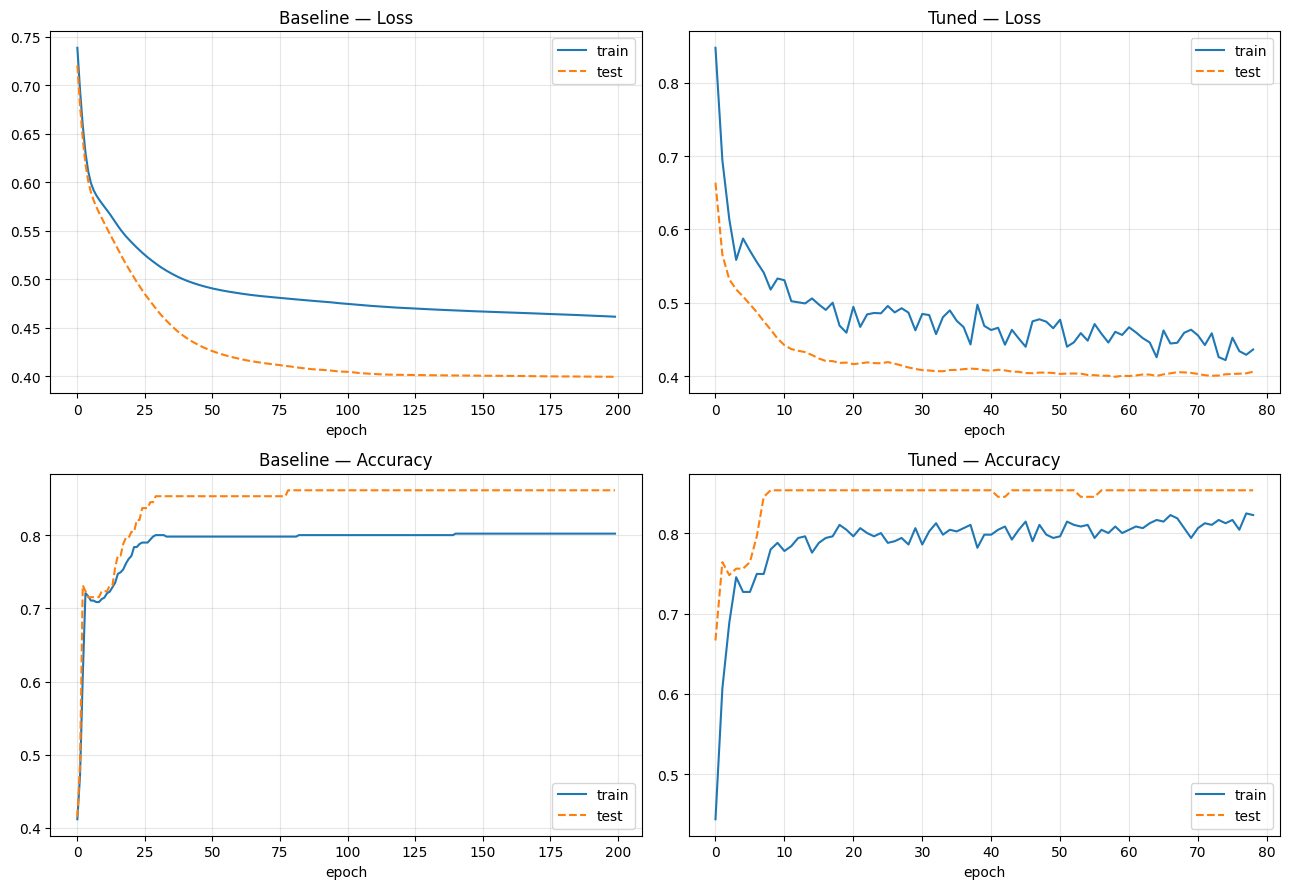

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
for col, (h, name) in enumerate([(hist_base, "Baseline"), (hist_tuned, "Tuned")]):
    ax[0, col].plot(h.history["loss"], label="train")
    ax[0, col].plot(h.history["val_loss"], "--", label="test")
    ax[0, col].set_title(name + " — Loss")
    ax[1, col].plot(h.history["accuracy"], label="train")
    ax[1, col].plot(h.history["val_accuracy"], "--", label="test")
    ax[1, col].set_title(name + " — Accuracy")
for a in ax.ravel(): a.set_xlabel("epoch"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Final takeaways
- The **tuned** model shows a smaller train–test gap (BatchNorm + Dropout + early stopping all fight overfitting) and trains stably (He init + gradient clipping).
- On this small, easy dataset raw accuracy may only move a little — the *reliability* and *shape* of training is what improves. On larger, harder data these techniques compound into big gains.
- The workflow you just practised — **change one thing, plot train vs test, compare** — is the core loop of deep-learning experimentation.

### The full series
1. Baseline → 2. Optimizers → 3. Weight init → 4. Early stopping → 5. Gradient clipping → 6. BatchNorm → 7. Dropout → 8. Save/Load → 9. This comparison.

Each has a matching **PyTorch** notebook (`*_pytorch.ipynb`) implementing the same idea with an explicit training loop — compare the two to see what Keras does for you under the hood.